# 01 · Colour–magnitude diagram and red sequence of A2199

Builds the (g − r) vs. r colour–magnitude diagram of galaxies within 35′ of A2199, fits the red sequence to bright spectroscopic members, splits members into red and blue populations, and compares the fit with literature red sequences.

**Inputs**
- `DATA/AllHeCS_VAC_updated.csv` – HeCS-omnibus cluster catalog (cluster redshift)
- `DATA/A2199/A2199_mastercat_within35arcmin.csv` – A2199 master catalog (photometry, redshifts, membership)

**Output**
- `FIGURE/images/A2199_red_sequence.pdf`

In [1]:
# ============================================================================
# Setup
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.cosmology import LambdaCDM

# Cosmology used throughout this project
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# Matplotlib style shared by the notebooks of this repository
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "bold",
    'font.size': 25,
    'font.weight': 'normal',

    # Ticks: inwards, on all four sides, with minor ticks
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,

    # Axes and lines
    'lines.linewidth': 2,
    'axes.linewidth': 3.5,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Show every column when a DataFrame is displayed
pd.set_option('display.max_columns', None)

## Load the catalog and correct for Galactic extinction

Model magnitudes are used for colours, Petrosian magnitudes for total brightness. Extinction-corrected columns get the suffix `_0`.

In [2]:
# Cluster redshift from the HeCS-omnibus cluster table
hecs_vac_data = pd.read_csv('../../DATA/AllHeCS_VAC_updated.csv')
Z_CLID = hecs_vac_data[hecs_vac_data['CLID'] == 'A2199']['Z'].values[0]

# A2199 master catalog (all SDSS objects within 35 arcmin of the cluster centre)
df0 = pd.read_csv('../../DATA/A2199/A2199_mastercat_within35arcmin.csv')

# Galactic-extinction-corrected model and Petrosian magnitudes (suffix "_0")
for band in ['u', 'g', 'r', 'i', 'z']:
    df0[f'p_modelmag_{band}_0'] = df0[f'p_modelmag_{band}'] - df0[f'p_extinction_{band}']
for band in ['u', 'g', 'r', 'i', 'z']:
    df0[f'p_petromag_{band}_0'] = df0[f'p_petromag_{band}'] - df0[f'p_extinction_{band}']

# Galaxies only (visual classification flag), within 35 arcmin
df = df0[(df0['galaxyflag'] == 1) & (df0['p_radgal'] <= 35)]

## Colour–magnitude diagram and red-sequence fit

- grey: galaxies without a spectroscopic redshift; green: with a redshift
- red circles / blue crosses: members on / below the red sequence
- The red sequence is a linear fit to bright (r < 18), red (g − r > 0.5) members within 30′. Blue members lie more than 3σ below the fit, where σ is the scatter of the fitting sample.
- Literature red sequences: Song et al. (2017, A2199), Kang et al. (2024, Perseus), Kang et al. (2025, Coma), Park et al. (2026, MACH)

Red Sequence (This study): y = (-0.033 +/- 0.004)x + (1.28 +/- 0.07)
Scatter (sigma): 0.064


/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_16288/246530926.py:47: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(blue_members['p_petromag_r_0'], blue_members['g_r'],


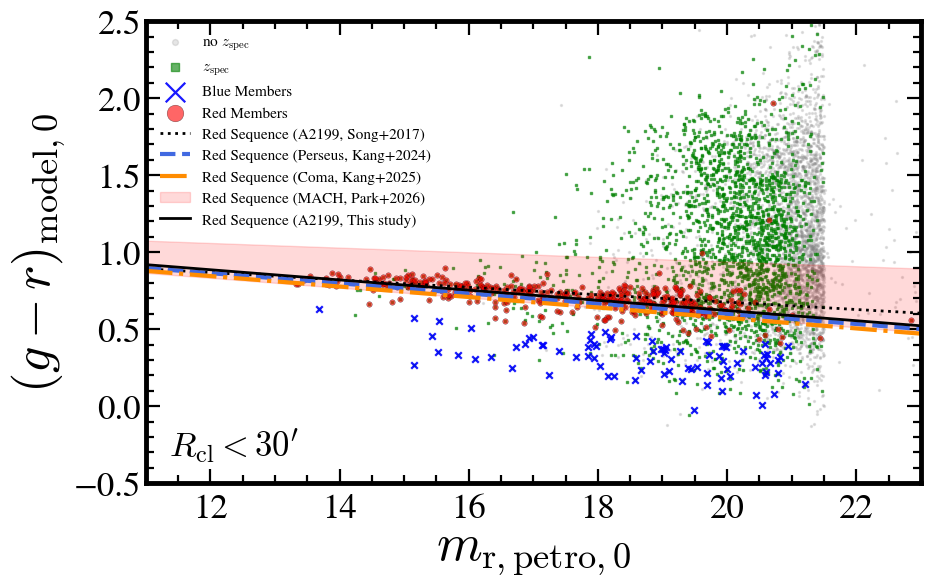

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

# ---- 1. Full sample: with / without spectroscopic redshift ----
mask_no_specz = df['z_tot_z'] == -9
mask_specz = df['z_tot_z'] != -9
mask_member = df['member'] == 'Y'

ax.scatter(df.loc[mask_no_specz, 'p_petromag_r_0'],
           df.loc[mask_no_specz, 'p_modelmag_g_0'] - df.loc[mask_no_specz, 'p_modelmag_r_0'],
           s=2, color='gray', alpha=0.2, label=r'no $z_\mathrm{spec}$')

ax.scatter(df.loc[mask_specz, 'p_petromag_r_0'],
           df.loc[mask_specz, 'p_modelmag_g_0'] - df.loc[mask_specz, 'p_modelmag_r_0'],
           s=4, color='green', alpha=0.6, marker='s', label=r'$z_\mathrm{spec}$')

# ---- 2. Red-sequence fit to bright, red members in the cluster core ----
bright_members = df[
    (df['member'] == 'Y') &
    (df['p_radgal'] <= 30) &
    ((df['p_modelmag_g_0'] - df['p_modelmag_r_0']) > 0.5) &
    (df['p_petromag_r_0'] < 18)
].copy()

x_fit = bright_members['p_petromag_r_0']
y_fit = bright_members['p_modelmag_g_0'] - bright_members['p_modelmag_r_0']

# Linear fit with covariance for the parameter errors
p_opt, p_cov = np.polyfit(x_fit, y_fit, 1, cov=True)
slope, intercept = p_opt
slope_err, intercept_err = np.sqrt(np.diag(p_cov))

# Scatter of the fitting sample about the fit; defines the red/blue boundary below
sigma = np.std(y_fit - (slope * x_fit + intercept))

print(f'Red Sequence (This study): y = ({slope:.3f} +/- {slope_err:.3f})x + ({intercept:.2f} +/- {intercept_err:.2f})')
print(f'Scatter (sigma): {sigma:.3f}')

# ---- 3. Classify all members: blue = more than 3 sigma below the red sequence ----
df_members_all = df[df['member'] == 'Y'].copy()
df_members_all['g_r'] = df_members_all['p_modelmag_g_0'] - df_members_all['p_modelmag_r_0']
df_members_all['g_r_pred'] = slope * df_members_all['p_petromag_r_0'] + intercept
df_members_all['residual'] = df_members_all['g_r'] - df_members_all['g_r_pred']

blue_members = df_members_all[df_members_all['residual'] < -3 * sigma]
red_members = df_members_all[df_members_all['residual'] >= -3 * sigma]

ax.scatter(blue_members['p_petromag_r_0'], blue_members['g_r'],
           s=22, color='blue', alpha=0.9, edgecolors='black', linewidths=1.6, marker='x', label='Blue Members')
ax.scatter(red_members['p_petromag_r_0'], red_members['g_r'],
           s=16, color='red', alpha=0.6, edgecolors='black', linewidths=0.3, marker='o', label='Red Members')

# ---- 4. Literature red sequences and this study ----
x_vals = np.linspace(11, 23, 500)

# Song et al. (2017), A2199
ax.plot(x_vals, 1.156 - 0.024 * x_vals, color='black', linewidth=2.0, ls='dotted',
        label='Red Sequence (A2199, Song+2017)')

# Kang et al. (2024), Perseus
ax.plot(x_vals, 1.26 - 0.033 * x_vals, color='royalblue', linewidth=3.0, ls='--',
        label='Red Sequence (Perseus, Kang+2024)')

# Kang et al. (2025), Coma
ax.plot(x_vals, 1.253 - 0.034 * x_vals, color='darkorange', linewidth=3.0, ls='-.',
        label='Red Sequence (Coma, Kang+2025)')

# Park et al. (2026), MACH clusters: slope/intercept with 1-sigma band
slope_p, intercept_p = -0.0236, 1.23
slope_err_p, intercept_err_p = 0.0085, 0.0113
y_upper_p = (slope_p + slope_err_p) * x_vals + (intercept_p + intercept_err_p)
y_lower_p = (slope_p - slope_err_p) * x_vals + (intercept_p - intercept_err_p)
ax.fill_between(x_vals, y_lower_p, y_upper_p, color='red', alpha=0.15, label='Red Sequence (MACH, Park+2026)')

# This study
ax.plot(x_vals, intercept + slope * x_vals, color='black', linewidth=2.0, ls='-',
        label='Red Sequence (A2199, This study)')

# ---- 5. Axes and legend ----
ax.set_xlim(11, 23)
ax.set_ylim(-0.5, 2.5)
ax.set_xlabel(r'$m_\mathrm{r,petro, 0}$', fontsize=37.5)
ax.set_ylabel(r'$(g - r)_\mathrm{model, 0}$', fontsize=37.5)
ax.text(0.03, 0.06, r'$R_\mathrm{cl}<30^\prime$', fontsize=25, transform=ax.transAxes)
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.minorticks_on()
ax.legend(markerscale=3, loc='upper left', fontsize=11, frameon=False, ncol=1)

plt.savefig('../../FIGURE/images/A2199_red_sequence.pdf', format='pdf', dpi=300, bbox_inches='tight')

## Robustness check: iterative 3σ clipping

Refit the red sequence while iteratively removing members that deviate by more than 3σ, to check that the single-pass fit above is stable.

In [4]:
from scipy.stats import linregress

r_limit = 18
print(f"\n--- Iterative 3-Sigma Clipping Test (r < {r_limit}) ---")
print(f"{'Iter':<5} {'Slope':<9} {'Slope_Err':<10} {'Intercept':<10} {'Int_Err':<10} {'Sigma':<8} {'N_rem':<6} {'N_out'}")
print("-" * 85)

# Same starting sample as the fit above
current_data = df[
    (df['member'] == 'Y') &
    (df['p_radgal'] <= 30) &
    ((df['p_modelmag_g_0'] - df['p_modelmag_r_0']) > 0.5) &
    (df['p_petromag_r_0'] < r_limit)
].copy()

iteration = 0
max_iter = 10          # safety limit

while iteration < max_iter:
    iteration += 1

    X = current_data['p_petromag_r_0'].values
    y = current_data['p_modelmag_g_0'].values - current_data['p_modelmag_r_0'].values

    res = linregress(X, y)     # slope, intercept, stderr (slope error), intercept_stderr

    try:
        int_err = res.intercept_stderr
    except AttributeError:     # SciPy < 1.6
        int_err = res.stderr * np.sqrt(np.mean(X**2))

    residuals = y - (res.slope * X + res.intercept)
    sigma = np.std(residuals)

    is_outlier = np.abs(residuals) > 3 * sigma
    n_outliers = np.sum(is_outlier)

    print(f"{iteration:<5} {res.slope:.3f}    {res.stderr:.3f}     {res.intercept:.3f}     {int_err:.3f}     {sigma:.3f}   {len(current_data):<6} {n_outliers}")

    if n_outliers == 0:
        print("-" * 85)
        print("Convergence reached!")
        print(f"Final: y = ({res.slope:.3f} +/- {res.stderr:.3f})x + ({res.intercept:.3f} +/- {int_err:.3f})")
        break

    current_data = current_data[~is_outlier].copy()


--- Iterative 3-Sigma Clipping Test (r < 18) ---
Iter  Slope     Slope_Err  Intercept  Int_Err    Sigma    N_rem  N_out
-------------------------------------------------------------------------------------
1     -0.033    0.004     1.283     0.071     0.064   163    3
2     -0.034    0.004     1.309     0.063     0.057   160    3
3     -0.032    0.004     1.267     0.057     0.051   157    1
4     -0.031    0.003     1.262     0.055     0.050   156    2
5     -0.032    0.003     1.269     0.053     0.047   154    1
6     -0.031    0.003     1.258     0.051     0.046   153    0
-------------------------------------------------------------------------------------
Convergence reached!
Final: y = (-0.031 +/- 0.003)x + (1.258 +/- 0.051)
